# Data Profiler 

## Part-A : Fundamentals

## 1) Write a short note : What is Data Analysis?


**Data Analysis** : 

Data analysis is the process of inspecting, cleaning, transforming, and modeling data to discover useful information, draw conclusions, and support decision-making.
Key Stages:

- **Data Collection** – Gathering raw data from sources like surveys, databases, sensors, or APIs.
- **Data Cleaning** – Handling missing values, removing duplicates, and correcting errors to ensure data quality.
- **Exploratory Data Analysis (EDA)** – Using statistics and visualizations to understand patterns, distributions, and relationships.
- **Data Transformation** – Normalizing, aggregating, or reshaping data to make it suitable for analysis.
- **Modeling & Interpretation** – Applying statistical or machine learning models to extract insights.
- **Visualization & Reporting** – Presenting findings through charts, dashboards, or reports for stakeholders.

Types of Data Analysis:

1) **Descriptive** – Summarizes what happened (e.g., sales last quarter).
2) **Diagnostic** – Explains why it happened (e.g., why sales dropped).
3) **Predictive** – Forecasts what might happen (e.g., next quarter's sales).
4) **Prescriptive** – Recommends actions to take (e.g., adjust pricing strategy).

Common Tools: Python (Pandas, NumPy), R, SQL, Excel, Tableau, Power BI.

## 2)Describe how to plan a **Data Science Project** , listing all steps.

1. **Problem definition** is the foundation. Everything downstream depends on getting this right. You need to answer: What exactly are we trying to predict or decide? How will success be measured? Who are the stakeholders? A vague problem leads to wasted effort across all other steps.

2. **Data collection strategy** follows once you know what you need. You identify relevant data sources (databases, APIs, surveys, logs), plan how to label or acquire it, and address storage, access, and legal/privacy concerns early — before you've invested weeks in modelling.

3. **EDA + data engineering** is where most of the actual work lives. Exploratory analysis reveals the true shape of your data — skewness, null patterns, outliers, correlations. Data engineering then cleans and transforms it, engineers useful features, and builds reproducible pipelines so the process can be re-run.

4. **Model selection** means matching the right algorithm to the problem. Start with a simple baseline (even a linear model), benchmark it, then experiment with more complex alternatives. Track every experiment — hyperparameters, metrics, and data versions.

5. **Evaluation** is where you honestly test the model against unseen data using the metrics you agreed on in step 1. Check for fairness issues, generalization gaps, and whether the model actually moves the business needle. Stakeholder sign-off happens here.

6. **Deployment & monitoring** closes the loop. The model is served (via API, batch pipeline, or embedded), but the job isn't done. Real-world data drifts over time — monitoring tracks performance degradation and triggers retraining cycles when needed.

## 3) Frame a **Machine Learning Problem Statement** : Predict whether a customer will churn based on purchase behaviour.

- **Task type** — This is a supervised binary classification problem. Each customer gets a label (churned or not), and the model learns patterns that distinguish the two groups.

- **Target variable** — "Churn" must be precisely defined before any modelling. A common definition is: no purchase in the last 90 days, or a cancellation/unsubscribe event. Without a crisp definition, your labels are noisy and your model will underperform.

- **Input features** — The RFM framework (Recency, Frequency, Monetary) forms the backbone of purchase-behaviour features. You'd extend it with trend signals (is the customer buying less over time?) and category-level signals (return rate, category breadth).

- **Evaluation metrics** — Accuracy is a poor choice here because of class imbalance. ROC-AUC is the primary metric, but recall is especially important — missing a churner who then leaves is far costlier than a false alarm. F1-score balances both.

- **Constraints** — Class imbalance (churners are a minority) is the biggest technical challenge; techniques like SMOTE, class weights, or threshold tuning are needed. Interpretability is often a business requirement — stakeholders want to know why a customer is flagged.

- **Candidate models** — Always start with logistic regression as a baseline. XGBoost or LightGBM are typically the best performers for tabular purchase data and naturally provide feature importance scores, which help with interpretability.

- **Success criteria** — Define both a technical threshold (ROC-AUC > 0.80) and a business outcome (reduce monthly churn by 5%). Without the business metric, you can't prove the model created real value.

## Explain : 

- What are **Tensors**?
- Provide an **in-depth explaination** of tensors with simple examples using Numpy.

### What are Tensors?

- Multi-dimensional array of numbers — a container that stores numbers in an organized way across any number of dimensions.

### Provide an **in-depth explaination** of tensors with simple examples using numpy.

In [1]:
# frame = np.zeros((3, 1080, 1920), dtype=np.uint8)
# frame.shape   
# frame.size    

In [2]:
print("Here's the example of tensor.")
print()
print("3D tensor One frame : color image tensor.")
print("A 1920×1080 HD frame has three color channels: R, G, and B.")

Here's the example of tensor.

3D tensor One frame : color image tensor.
A 1920×1080 HD frame has three color channels: R, G, and B.


## Part-B : Data Acquisition

### 5) Load datasets from different sources :

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sqlite3 
import requests
import os

#### Load dataset from csv

In [4]:
Data1 = pd.read_csv("employees_practice.csv")
Data1

,employee_id,gender,age,department,city,salary,experience_years,joining_date,performance_score,status
0,EMP0237,Male,42,HR,Pune,89657.97,19.4,2016-01-14,3.5,Resigned
1,EMP0660,Male,40,HR,Bangalore,77675.20,17.9,2017-06-04,3.5,Resigned
2,EMP0894,Male,26,Product,Hyderabad,77149.63,2.6,2020-09-03,4.0,Active
3,EMP0841,Male,24,Engineering,Hyderabad,72891.50,2.9,2016-01-04,3.1,Resigned
4,EMP0113,Female,26,HR,Kolkata,53561.63,2.8,2021-08-02,2.0,Probation
...,...,...,...,...,...,...,...,...,...,...
995,EMP0205,NaN,32,Finance,Ahmedabad,87489.86,7.8,2017-02-26,2.2,Active
996,EMP0390,Male,33,Finance,Pune,89878.13,10.7,2023-05-31,2.7,Active
997,EMP0310,Male,44,Marketing,Chennai,87062.28,19.5,2022-11-01,3.1,On Leave
998,EMP0020,Female,40,Sales,Ahmedabad,70911.41,13.5,2017-09-22,4.7,On Leave


#### Load dataset from json

In [5]:
with open("employees_practice.json") as file:
    raw = json.load(file)

Data2 = pd.json_normalize(
    raw,
    record_path=['employees']
)
Data2

M_Data2 = pd.DataFrame(Data2)
M_Data2

,employee_id,skills,projects,personal.name,personal.gender,personal.age,personal.city,personal.education,job.department,job.designation,job.status,job.joining_date,job.experience_years,compensation.salary,compensation.bonus,compensation.bank,compensation.currency,performance.score,performance.reviews_completed,performance.promoted
0,EMP0001,"[CRM, Salesforce, Negotiation]","[{'project_id': 'PRJ979', 'name': 'Beta_1', 's...",Employee_0001,Female,45,Delhi,B.Tech,Sales,Intern,Active,2017-07-03,19.0,85235.33,NaN,Kotak,INR,4.0,3,True
1,EMP0002,"[Python, SQL]","[{'project_id': 'PRJ996', 'name': 'Gamma_2', '...",Employee_0002,Female,36,Kolkata,BCA,Engineering,Intern,On Leave,2019-01-21,11.8,97732.74,16532.17,HDFC,INR,3.7,4,False
2,EMP0003,"[SAP, Python, Financial Modeling, Excel]","[{'project_id': 'PRJ123', 'name': 'Delta_3', '...",Employee_0003,Female,33,Delhi,BCA,Finance,Junior,Active,2023-03-14,8.7,84450.53,12420.08,Axis,INR,4.2,6,False
3,EMP0004,"[SEO, Google Ads, Canva, Excel, Content Writing]","[{'project_id': 'PRJ951', 'name': 'Zeta_4', 's...",Employee_0004,Male,39,Rajkot,M.Tech,Marketing,Lead,Probation,2024-11-30,15.5,78733.31,NaN,HDFC,INR,3.5,3,True
4,EMP0005,"[Financial Modeling, Python]","[{'project_id': 'PRJ649', 'name': 'Alpha_5', '...",Employee_0005,Female,33,Delhi,M.Tech,Finance,Junior,Active,2015-10-03,7.7,87622.22,10172.42,Kotak,INR,2.2,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,EMP0196,"[SAP HR, Payroll, Excel]","[{'project_id': 'PRJ624', 'name': 'Sigma_196',...",Employee_0196,Female,38,Pune,BSc,HR,Manager,On Leave,2021-03-02,14.8,70407.46,12203.26,SBI,INR,2.5,0,False
196,EMP0197,"[SAP, Python, Financial Modeling]","[{'project_id': 'PRJ717', 'name': 'Omega_197',...",Employee_0197,Male,43,Pune,B.Com,Finance,Junior,Resigned,2023-01-26,17.9,106966.69,7910.44,ICICI,INR,1.8,1,True
197,EMP0198,"[Cold Calling, Salesforce, Negotiation]","[{'project_id': 'PRJ127', 'name': 'Zeta_198', ...",Employee_0198,Female,29,Hyderabad,MBA,Sales,Senior,Probation,2018-06-05,4.9,62273.10,5206.74,ICICI,INR,2.9,5,False
198,EMP0199,"[Cold Calling, Negotiation, CRM]","[{'project_id': 'PRJ665', 'name': 'Zeta_199', ...",Employee_0199,Male,32,Delhi,BSc,Sales,Junior,On Leave,2018-02-28,10.2,83591.48,11435.06,Axis,INR,3.3,4,False


Why pd.json_normalize()? The JSON has nested structure (e.g., employees[].personal.gender) — normalize flattens it into dot-notation columns like personal.gender.

#### Load datset from sql

##### Note : My SQl has some issues and it didn't connect my database or table which i was created so i'm aware of this csv transformtaion so do that.

conn = sqlite3.connect('retails.db')
cursor = conn.cursor()

df = pd.read_sql_query("SELECT * FROM retails WHERE amount > 40", conn)
print(df)

conn.close()


##### I tried this code to run my sql but it didn't working so tried convert csv and worked on it.

In [6]:
Data3 = pd.read_csv('customers(from sql).csv')
Data3

,customer_id,first_name,last_name,gender,email,city,state,signup_date
0,1,Danielle,Gould,Other,vporter@example.com,Lake James,Washington,2024-09-07
1,2,Angel,Strong,Male,erik19@example.net,South Amy,Massachusetts,2024-05-04
2,3,Joshua,Warner,Other,allenkimberly@example.com,Austinville,Vermont,2021-08-08
3,4,Jeffrey,Cannon,Other,meganwoods@example.com,North Josephport,South Dakota,2020-07-19
4,5,Jill,Johnson,Male,stanleyclark@example.org,Lake Courtneyport,West Virginia,2023-02-06
...,...,...,...,...,...,...,...,...
9995,9996,Sandra,Douglas,Other,stacey68@example.org,East James,Nevada,2024-04-23
9996,9997,Elizabeth,Morris,Male,brian18@example.org,West Johnmouth,North Dakota,2024-09-06
9997,9998,Natalie,Cole,Female,kyle02@example.com,Jerryport,Minnesota,2024-06-07
9998,9999,Joe,Doyle,Female,michael70@example.org,Denisestad,California,2022-07-26


#### Load dataset from the API

In [7]:
url = 'https://dummyjson.com/users'

response = requests.get(url)

data = response.json()

print(data)

{'users': [{'id': 1, 'firstName': 'Emily', 'lastName': 'Johnson', 'maidenName': 'Smith', 'age': 29, 'gender': 'female', 'email': 'emily.johnson@x.dummyjson.com', 'phone': '+81 965-431-3024', 'username': 'emilys', 'password': 'emilyspass', 'birthDate': '1996-5-30', 'image': 'https://dummyjson.com/icon/emilys/128', 'bloodGroup': 'O-', 'height': 193.24, 'weight': 63.16, 'eyeColor': 'Green', 'hair': {'color': 'Brown', 'type': 'Curly'}, 'ip': '42.48.100.32', 'address': {'address': '626 Main Street', 'city': 'Phoenix', 'state': 'Mississippi', 'stateCode': 'MS', 'postalCode': '29112', 'coordinates': {'lat': -77.16213, 'lng': -92.084824}, 'country': 'United States'}, 'macAddress': '47:fa:41:18:ec:eb', 'university': 'University of Wisconsin--Madison', 'bank': {'cardExpire': '05/28', 'cardNumber': '3693233511855044', 'cardType': 'Diners Club International', 'currency': 'GBP', 'iban': 'GB74MH2UZLR9TRPHYNU8F8'}, 'company': {'department': 'Engineering', 'name': 'Dooley, Kozey and Cronin', 'title': 

In [8]:
Data4 = pd.DataFrame(data['users'])
Data4

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
5,6,Olivia,Wilson,,23,female,olivia.wilson@x.dummyjson.com,+91 607-295-6448,oliviaw,oliviawpass,...,"{'address': '547 First Street', 'city': 'Fort ...",9c:7f:ea:34:18:19,University of North Carolina--Chapel Hill,"{'cardExpire': '06/30', 'cardNumber': '3763200...","{'department': 'Product Management', 'name': '...",921-709,836-772-168,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",moderator
6,7,Alexander,Jones,,39,male,alexander.jones@x.dummyjson.com,+61 260-824-4986,alexanderj,alexanderjpass,...,"{'address': '664 Maple Street', 'city': 'India...",d2:64:58:2d:1c:46,University of Illinois--Urbana-Champaign,"{'cardExpire': '12/29', 'cardNumber': '5189302...","{'department': 'Engineering', 'name': 'Dickens...",638-127,722-993-925,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",moderator
7,8,Ava,Taylor,,28,female,ava.taylor@x.dummyjson.com,+1 458-853-7877,avat,avatpass,...,"{'address': '1197 First Street', 'city': 'Fort...",8d:2e:c2:d6:e7:a8,University of Wisconsin--Madison,"{'cardExpire': '08/30', 'cardNumber': '5349974...","{'department': 'Marketing', 'name': 'Nikolaus ...",297-762,257-419-109,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",moderator
8,9,Ethan,Martinez,,34,male,ethan.martinez@x.dummyjson.com,+92 933-608-5081,ethanm,ethanmpass,...,"{'address': '466 Pine Street', 'city': 'San An...",59:e:9e:e3:29:da,Syracuse University,"{'cardExpire': '10/27', 'cardNumber': '3598603...","{'department': 'Support', 'name': 'Gorczany - ...",790-434,569-650-348,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitc

## Part-C : Data Understanding and Cleaning

### 6)Perform **initial explotration** :

#### Headers

In [9]:
Data1.head()

,employee_id,gender,age,department,city,salary,experience_years,joining_date,performance_score,status
0,EMP0237,Male,42,HR,Pune,89657.97,19.4,2016-01-14,3.5,Resigned
1,EMP0660,Male,40,HR,Bangalore,77675.20,17.9,2017-06-04,3.5,Resigned
2,EMP0894,Male,26,Product,Hyderabad,77149.63,2.6,2020-09-03,4.0,Active
3,EMP0841,Male,24,Engineering,Hyderabad,72891.50,2.9,2016-01-04,3.1,Resigned
4,EMP0113,Female,26,HR,Kolkata,53561.63,2.8,2021-08-02,2.0,Probation


In [10]:
Data2.head()

,employee_id,skills,projects,personal.name,personal.gender,personal.age,personal.city,personal.education,job.department,job.designation,job.status,job.joining_date,job.experience_years,compensation.salary,compensation.bonus,compensation.bank,compensation.currency,performance.score,performance.reviews_completed,performance.promoted
0,EMP0001,"[CRM, Salesforce, Negotiation]","[{'project_id': 'PRJ979', 'name': 'Beta_1', 's...",Employee_0001,Female,45,Delhi,B.Tech,Sales,Intern,Active,2017-07-03,19.0,85235.33,NaN,Kotak,INR,4.0,3,True
1,EMP0002,"[Python, SQL]","[{'project_id': 'PRJ996', 'name': 'Gamma_2', '...",Employee_0002,Female,36,Kolkata,BCA,Engineering,Intern,On Leave,2019-01-21,11.8,97732.74,16532.17,HDFC,INR,3.7,4,False
2,EMP0003,"[SAP, Python, Financial Modeling, Excel]","[{'project_id': 'PRJ123', 'name': 'Delta_3', '...",Employee_0003,Female,33,Delhi,BCA,Finance,Junior,Active,2023-03-14,8.7,84450.53,12420.08,Axis,INR,4.2,6,False
3,EMP0004,"[SEO, Google Ads, Canva, Excel, Content Writing]","[{'project_id': 'PRJ951', 'name': 'Zeta_4', 's...",Employee_0004,Male,39,Rajkot,M.Tech,Marketing,Lead,Probation,2024-11-30,15.5,78733.31,NaN,HDFC,INR,3.5,3,True
4,EMP0005,"[Financial Modeling, Python]","[{'project_id': 'PRJ649', 'name': 'Alpha_5', '...",Employee_0005,Female,33,Delhi,M.Tech,Finance,Junior,Active,2015-10-03,7.7,87622.22,10172.42,Kotak,INR,2.2,0,False


In [11]:
Data3.head()

,customer_id,first_name,last_name,gender,email,city,state,signup_date
0,1,Danielle,Gould,Other,vporter@example.com,Lake James,Washington,2024-09-07
1,2,Angel,Strong,Male,erik19@example.net,South Amy,Massachusetts,2024-05-04
2,3,Joshua,Warner,Other,allenkimberly@example.com,Austinville,Vermont,2021-08-08
3,4,Jeffrey,Cannon,Other,meganwoods@example.com,North Josephport,South Dakota,2020-07-19
4,5,Jill,Johnson,Male,stanleyclark@example.org,Lake Courtneyport,West Virginia,2023-02-06


In [12]:
Data4.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


#### Infos

In [13]:
Data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        1000 non-null   object 
 1   gender             941 non-null    object 
 2   age                1000 non-null   int64  
 3   department         1000 non-null   object 
 4   city               952 non-null    object 
 5   salary             1000 non-null   float64
 6   experience_years   954 non-null    float64
 7   joining_date       1000 non-null   object 
 8   performance_score  942 non-null    float64
 9   status             1000 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB


In [14]:
Data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   employee_id                    200 non-null    object 
 1   skills                         200 non-null    object 
 2   projects                       200 non-null    object 
 3   personal.name                  200 non-null    object 
 4   personal.gender                189 non-null    object 
 5   personal.age                   200 non-null    int64  
 6   personal.city                  187 non-null    object 
 7   personal.education             200 non-null    object 
 8   job.department                 200 non-null    object 
 9   job.designation                200 non-null    object 
 10  job.status                     200 non-null    object 
 11  job.joining_date               200 non-null    object 
 12  job.experience_years           191 non-null    flo

In [15]:
Data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  10000 non-null  int64 
 1   first_name   10000 non-null  object
 2   last_name    10000 non-null  object
 3   gender       10000 non-null  object
 4   email        10000 non-null  object
 5   city         10000 non-null  object
 6   state        10000 non-null  object
 7   signup_date  10000 non-null  object
dtypes: int64(1), object(7)
memory usage: 625.1+ KB


In [16]:
Data4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          30 non-null     int64  
 1   firstName   30 non-null     object 
 2   lastName    30 non-null     object 
 3   maidenName  30 non-null     object 
 4   age         30 non-null     int64  
 5   gender      30 non-null     object 
 6   email       30 non-null     object 
 7   phone       30 non-null     object 
 8   username    30 non-null     object 
 9   password    30 non-null     object 
 10  birthDate   30 non-null     object 
 11  image       30 non-null     object 
 12  bloodGroup  30 non-null     object 
 13  height      30 non-null     float64
 14  weight      30 non-null     float64
 15  eyeColor    30 non-null     object 
 16  hair        30 non-null     object 
 17  ip          30 non-null     object 
 18  address     30 non-null     object 
 19  macAddress  30 non-null     obj

#### Describes

In [17]:
Data1.describe()

,age,salary,experience_years,performance_score
count,1000.000000,1000.000000,954.000000,942.000000
mean,34.087000,80983.130230,10.101572,3.198938
std,5.909175,16991.737021,5.715534,0.699111
min,22.000000,48291.960000,0.500000,1.000000
25%,29.000000,67690.417500,5.200000,2.800000
50%,34.000000,79889.010000,9.950000,3.200000
75%,39.000000,92810.352500,15.000000,3.700000
max,46.000000,130971.710000,20.000000,5.000000


In [18]:
Data2.describe()

,personal.age,job.experience_years,compensation.salary,compensation.bonus,performance.score,performance.reviews_completed
count,200.00000,191.000000,200.000000,182.000000,193.000000,200.000000
mean,34.52000,10.597382,82891.717200,9891.134451,3.104663,3.665000
std,6.02504,5.675473,16505.699752,3970.487762,0.701879,2.626264
min,22.00000,0.600000,47246.800000,2528.650000,1.200000,0.000000
25%,29.00000,5.350000,71863.397500,6943.930000,2.500000,1.000000
50%,35.00000,11.600000,82616.140000,9382.965000,3.100000,4.000000
75%,39.25000,15.550000,93511.115000,12705.365000,3.600000,6.000000
max,45.00000,19.900000,119901.750000,22277.370000,5.000000,8.000000


In [19]:
Data3.describe()

,customer_id
count,10000.00000
mean,5000.50000
std,2886.89568
min,1.00000
25%,2500.75000
50%,5000.50000
75%,7500.25000
max,10000.00000


In [20]:
Data4.describe()

,id,age,height,weight
count,30.000000,30.000000,30.000000,30.000000
mean,15.500000,33.566667,178.978333,70.730333
std,8.803408,5.721607,12.072711,13.169899
min,1.000000,23.000000,150.560000,50.100000
25%,8.250000,29.250000,172.812500,58.847500
50%,15.500000,33.000000,182.015000,70.960000
75%,22.750000,37.750000,187.657500,81.677500
max,30.000000,46.000000,195.330000,95.840000


#### Identifying Missing Values

In [21]:
Data1.isnull().sum()

employee_id           0
gender               59
age                   0
department            0
city                 48
salary                0
experience_years     46
joining_date          0
performance_score    58
status                0
dtype: int64

In [22]:
M_Data2.isnull().sum()

employee_id                       0
skills                            0
projects                          0
personal.name                     0
personal.gender                  11
personal.age                      0
personal.city                    13
personal.education                0
job.department                    0
job.designation                   0
job.status                        0
job.joining_date                  0
job.experience_years              9
compensation.salary               0
compensation.bonus               18
compensation.bank                 0
compensation.currency             0
performance.score                 7
performance.reviews_completed     0
performance.promoted              0
dtype: int64

In [23]:
Data3.isnull().sum()

customer_id    0
first_name     0
last_name      0
gender         0
email          0
city           0
state          0
signup_date    0
dtype: int64

In [24]:
Data4.isnull().sum()

id            0
firstName     0
lastName      0
maidenName    0
age           0
gender        0
email         0
phone         0
username      0
password      0
birthDate     0
image         0
bloodGroup    0
height        0
weight        0
eyeColor      0
hair          0
ip            0
address       0
macAddress    0
university    0
bank          0
company       0
ein           0
ssn           0
userAgent     0
crypto        0
role          0
dtype: int64

#### Duplicated values

In [25]:
Data1.duplicated().sum()

np.int64(25)

#### **Note** : Data2 is unhasahable so there are no duplicated count of Data2 

In [26]:
Data3.duplicated().sum()

np.int64(0)

#### **Note** : Data4 is also unhasahable so there are no duplicated count of Data4

Data2 and Data4 flagged as "unhashable" for duplicate checks — because those DataFrames contain columns with list/dict values that Pandas can't hash for duplicate detection.

### 7)Apply Data cleaning : 

#### Handle missing data (imputation or removal)

In [27]:
Data1.fillna(Data1.mode())

,employee_id,gender,age,department,city,salary,experience_years,joining_date,performance_score,status
0,EMP0237,Male,42,HR,Pune,89657.97,19.4,2016-01-14,3.5,Resigned
1,EMP0660,Male,40,HR,Bangalore,77675.20,17.9,2017-06-04,3.5,Resigned
2,EMP0894,Male,26,Product,Hyderabad,77149.63,2.6,2020-09-03,4.0,Active
3,EMP0841,Male,24,Engineering,Hyderabad,72891.50,2.9,2016-01-04,3.1,Resigned
4,EMP0113,Female,26,HR,Kolkata,53561.63,2.8,2021-08-02,2.0,Probation
...,...,...,...,...,...,...,...,...,...,...
995,EMP0205,NaN,32,Finance,Ahmedabad,87489.86,7.8,2017-02-26,2.2,Active
996,EMP0390,Male,33,Finance,Pune,89878.13,10.7,2023-05-31,2.7,Active
997,EMP0310,Male,44,Marketing,Chennai,87062.28,19.5,2022-11-01,3.1,On Leave
998,EMP0020,Female,40,Sales,Ahmedabad,70911.41,13.5,2017-09-22,4.7,On Leave


In [28]:
M_Data2.fillna(Data2[('personal.gender')].mode())

,employee_id,skills,projects,personal.name,personal.gender,personal.age,personal.city,personal.education,job.department,job.designation,job.status,job.joining_date,job.experience_years,compensation.salary,compensation.bonus,compensation.bank,compensation.currency,performance.score,performance.reviews_completed,performance.promoted
0,EMP0001,"[CRM, Salesforce, Negotiation]","[{'project_id': 'PRJ979', 'name': 'Beta_1', 's...",Employee_0001,Female,45,Delhi,B.Tech,Sales,Intern,Active,2017-07-03,19.0,85235.33,NaN,Kotak,INR,4.0,3,True
1,EMP0002,"[Python, SQL]","[{'project_id': 'PRJ996', 'name': 'Gamma_2', '...",Employee_0002,Female,36,Kolkata,BCA,Engineering,Intern,On Leave,2019-01-21,11.8,97732.74,16532.17,HDFC,INR,3.7,4,False
2,EMP0003,"[SAP, Python, Financial Modeling, Excel]","[{'project_id': 'PRJ123', 'name': 'Delta_3', '...",Employee_0003,Female,33,Delhi,BCA,Finance,Junior,Active,2023-03-14,8.7,84450.53,12420.08,Axis,INR,4.2,6,False
3,EMP0004,"[SEO, Google Ads, Canva, Excel, Content Writing]","[{'project_id': 'PRJ951', 'name': 'Zeta_4', 's...",Employee_0004,Male,39,Rajkot,M.Tech,Marketing,Lead,Probation,2024-11-30,15.5,78733.31,NaN,HDFC,INR,3.5,3,True
4,EMP0005,"[Financial Modeling, Python]","[{'project_id': 'PRJ649', 'name': 'Alpha_5', '...",Employee_0005,Female,33,Delhi,M.Tech,Finance,Junior,Active,2015-10-03,7.7,87622.22,10172.42,Kotak,INR,2.2,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,EMP0196,"[SAP HR, Payroll, Excel]","[{'project_id': 'PRJ624', 'name': 'Sigma_196',...",Employee_0196,Female,38,Pune,BSc,HR,Manager,On Leave,2021-03-02,14.8,70407.46,12203.26,SBI,INR,2.5,0,False
196,EMP0197,"[SAP, Python, Financial Modeling]","[{'project_id': 'PRJ717', 'name': 'Omega_197',...",Employee_0197,Male,43,Pune,B.Com,Finance,Junior,Resigned,2023-01-26,17.9,106966.69,7910.44,ICICI,INR,1.8,1,True
197,EMP0198,"[Cold Calling, Salesforce, Negotiation]","[{'project_id': 'PRJ127', 'name': 'Zeta_198', ...",Employee_0198,Female,29,Hyderabad,MBA,Sales,Senior,Probation,2018-06-05,4.9,62273.10,5206.74,ICICI,INR,2.9,5,False
198,EMP0199,"[Cold Calling, Negotiation, CRM]","[{'project_id': 'PRJ665', 'name': 'Zeta_199', ...",Employee_0199,Male,32,Delhi,BSc,Sales,Junior,On Leave,2018-02-28,10.2,83591.48,11435.06,Axis,INR,3.3,4,False


In [29]:
M_Data2.fillna(M_Data2[('personal.city')].mode())

,employee_id,skills,projects,personal.name,personal.gender,personal.age,personal.city,personal.education,job.department,job.designation,job.status,job.joining_date,job.experience_years,compensation.salary,compensation.bonus,compensation.bank,compensation.currency,performance.score,performance.reviews_completed,performance.promoted
0,EMP0001,"[CRM, Salesforce, Negotiation]","[{'project_id': 'PRJ979', 'name': 'Beta_1', 's...",Employee_0001,Female,45,Delhi,B.Tech,Sales,Intern,Active,2017-07-03,19.0,85235.33,NaN,Kotak,INR,4.0,3,True
1,EMP0002,"[Python, SQL]","[{'project_id': 'PRJ996', 'name': 'Gamma_2', '...",Employee_0002,Female,36,Kolkata,BCA,Engineering,Intern,On Leave,2019-01-21,11.8,97732.74,16532.17,HDFC,INR,3.7,4,False
2,EMP0003,"[SAP, Python, Financial Modeling, Excel]","[{'project_id': 'PRJ123', 'name': 'Delta_3', '...",Employee_0003,Female,33,Delhi,BCA,Finance,Junior,Active,2023-03-14,8.7,84450.53,12420.08,Axis,INR,4.2,6,False
3,EMP0004,"[SEO, Google Ads, Canva, Excel, Content Writing]","[{'project_id': 'PRJ951', 'name': 'Zeta_4', 's...",Employee_0004,Male,39,Rajkot,M.Tech,Marketing,Lead,Probation,2024-11-30,15.5,78733.31,NaN,HDFC,INR,3.5,3,True
4,EMP0005,"[Financial Modeling, Python]","[{'project_id': 'PRJ649', 'name': 'Alpha_5', '...",Employee_0005,Female,33,Delhi,M.Tech,Finance,Junior,Active,2015-10-03,7.7,87622.22,10172.42,Kotak,INR,2.2,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,EMP0196,"[SAP HR, Payroll, Excel]","[{'project_id': 'PRJ624', 'name': 'Sigma_196',...",Employee_0196,Female,38,Pune,BSc,HR,Manager,On Leave,2021-03-02,14.8,70407.46,12203.26,SBI,INR,2.5,0,False
196,EMP0197,"[SAP, Python, Financial Modeling]","[{'project_id': 'PRJ717', 'name': 'Omega_197',...",Employee_0197,Male,43,Pune,B.Com,Finance,Junior,Resigned,2023-01-26,17.9,106966.69,7910.44,ICICI,INR,1.8,1,True
197,EMP0198,"[Cold Calling, Salesforce, Negotiation]","[{'project_id': 'PRJ127', 'name': 'Zeta_198', ...",Employee_0198,Female,29,Hyderabad,MBA,Sales,Senior,Probation,2018-06-05,4.9,62273.10,5206.74,ICICI,INR,2.9,5,False
198,EMP0199,"[Cold Calling, Negotiation, CRM]","[{'project_id': 'PRJ665', 'name': 'Zeta_199', ...",Employee_0199,Male,32,Delhi,BSc,Sales,Junior,On Leave,2018-02-28,10.2,83591.48,11435.06,Axis,INR,3.3,4,False


In [30]:
M_Data2.fillna(M_Data2[('compensation.bonus')])

,employee_id,skills,projects,personal.name,personal.gender,personal.age,personal.city,personal.education,job.department,job.designation,job.status,job.joining_date,job.experience_years,compensation.salary,compensation.bonus,compensation.bank,compensation.currency,performance.score,performance.reviews_completed,performance.promoted
0,EMP0001,"[CRM, Salesforce, Negotiation]","[{'project_id': 'PRJ979', 'name': 'Beta_1', 's...",Employee_0001,Female,45,Delhi,B.Tech,Sales,Intern,Active,2017-07-03,19.0,85235.33,NaN,Kotak,INR,4.0,3,True
1,EMP0002,"[Python, SQL]","[{'project_id': 'PRJ996', 'name': 'Gamma_2', '...",Employee_0002,Female,36,Kolkata,BCA,Engineering,Intern,On Leave,2019-01-21,11.8,97732.74,16532.17,HDFC,INR,3.7,4,False
2,EMP0003,"[SAP, Python, Financial Modeling, Excel]","[{'project_id': 'PRJ123', 'name': 'Delta_3', '...",Employee_0003,Female,33,Delhi,BCA,Finance,Junior,Active,2023-03-14,8.7,84450.53,12420.08,Axis,INR,4.2,6,False
3,EMP0004,"[SEO, Google Ads, Canva, Excel, Content Writing]","[{'project_id': 'PRJ951', 'name': 'Zeta_4', 's...",Employee_0004,Male,39,Rajkot,M.Tech,Marketing,Lead,Probation,2024-11-30,15.5,78733.31,NaN,HDFC,INR,3.5,3,True
4,EMP0005,"[Financial Modeling, Python]","[{'project_id': 'PRJ649', 'name': 'Alpha_5', '...",Employee_0005,Female,33,Delhi,M.Tech,Finance,Junior,Active,2015-10-03,7.7,87622.22,10172.42,Kotak,INR,2.2,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,EMP0196,"[SAP HR, Payroll, Excel]","[{'project_id': 'PRJ624', 'name': 'Sigma_196',...",Employee_0196,Female,38,Pune,BSc,HR,Manager,On Leave,2021-03-02,14.8,70407.46,12203.26,SBI,INR,2.5,0,False
196,EMP0197,"[SAP, Python, Financial Modeling]","[{'project_id': 'PRJ717', 'name': 'Omega_197',...",Employee_0197,Male,43,Pune,B.Com,Finance,Junior,Resigned,2023-01-26,17.9,106966.69,7910.44,ICICI,INR,1.8,1,True
197,EMP0198,"[Cold Calling, Salesforce, Negotiation]","[{'project_id': 'PRJ127', 'name': 'Zeta_198', ...",Employee_0198,Female,29,Hyderabad,MBA,Sales,Senior,Probation,2018-06-05,4.9,62273.10,5206.74,ICICI,INR,2.9,5,False
198,EMP0199,"[Cold Calling, Negotiation, CRM]","[{'project_id': 'PRJ665', 'name': 'Zeta_199', ...",Employee_0199,Male,32,Delhi,BSc,Sales,Junior,On Leave,2018-02-28,10.2,83591.48,11435.06,Axis,INR,3.3,4,False


In [31]:
M_Data2.fillna(M_Data2[('performance.score')])

,employee_id,skills,projects,personal.name,personal.gender,personal.age,personal.city,personal.education,job.department,job.designation,job.status,job.joining_date,job.experience_years,compensation.salary,compensation.bonus,compensation.bank,compensation.currency,performance.score,performance.reviews_completed,performance.promoted
0,EMP0001,"[CRM, Salesforce, Negotiation]","[{'project_id': 'PRJ979', 'name': 'Beta_1', 's...",Employee_0001,Female,45,Delhi,B.Tech,Sales,Intern,Active,2017-07-03,19.0,85235.33,NaN,Kotak,INR,4.0,3,True
1,EMP0002,"[Python, SQL]","[{'project_id': 'PRJ996', 'name': 'Gamma_2', '...",Employee_0002,Female,36,Kolkata,BCA,Engineering,Intern,On Leave,2019-01-21,11.8,97732.74,16532.17,HDFC,INR,3.7,4,False
2,EMP0003,"[SAP, Python, Financial Modeling, Excel]","[{'project_id': 'PRJ123', 'name': 'Delta_3', '...",Employee_0003,Female,33,Delhi,BCA,Finance,Junior,Active,2023-03-14,8.7,84450.53,12420.08,Axis,INR,4.2,6,False
3,EMP0004,"[SEO, Google Ads, Canva, Excel, Content Writing]","[{'project_id': 'PRJ951', 'name': 'Zeta_4', 's...",Employee_0004,Male,39,Rajkot,M.Tech,Marketing,Lead,Probation,2024-11-30,15.5,78733.31,NaN,HDFC,INR,3.5,3,True
4,EMP0005,"[Financial Modeling, Python]","[{'project_id': 'PRJ649', 'name': 'Alpha_5', '...",Employee_0005,Female,33,Delhi,M.Tech,Finance,Junior,Active,2015-10-03,7.7,87622.22,10172.42,Kotak,INR,2.2,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,EMP0196,"[SAP HR, Payroll, Excel]","[{'project_id': 'PRJ624', 'name': 'Sigma_196',...",Employee_0196,Female,38,Pune,BSc,HR,Manager,On Leave,2021-03-02,14.8,70407.46,12203.26,SBI,INR,2.5,0,False
196,EMP0197,"[SAP, Python, Financial Modeling]","[{'project_id': 'PRJ717', 'name': 'Omega_197',...",Employee_0197,Male,43,Pune,B.Com,Finance,Junior,Resigned,2023-01-26,17.9,106966.69,7910.44,ICICI,INR,1.8,1,True
197,EMP0198,"[Cold Calling, Salesforce, Negotiation]","[{'project_id': 'PRJ127', 'name': 'Zeta_198', ...",Employee_0198,Female,29,Hyderabad,MBA,Sales,Senior,Probation,2018-06-05,4.9,62273.10,5206.74,ICICI,INR,2.9,5,False
198,EMP0199,"[Cold Calling, Negotiation, CRM]","[{'project_id': 'PRJ665', 'name': 'Zeta_199', ...",Employee_0199,Male,32,Delhi,BSc,Sales,Junior,On Leave,2018-02-28,10.2,83591.48,11435.06,Axis,INR,3.3,4,False


#### **Note** : Data3 & Data4 has 0 missing values.

Missing value handling (fillna):

- Data1 → filled with column mode (most frequent value)
- M_Data2 → filled individual nested columns (personal.gender, personal.city, compensation.bonus, performance.score) with their respective modes
- Data3 and Data4 had 0 missing values — skipped

#### Correct inconsistent Data types

In [32]:
Data1[('salary')].astype(int)

0      89657
1      77675
2      77149
3      72891
4      53561
       ...  
995    87489
996    89878
997    87062
998    70911
999    64518
Name: salary, Length: 1000, dtype: int64

#### **Note** : Data2's all column's datatypes are correct there are no need to change.

In [33]:
Data3[('customer_id')].astype(int)

0           1
1           2
2           3
3           4
4           5
        ...  
9995     9996
9996     9997
9997     9998
9998     9999
9999    10000
Name: customer_id, Length: 10000, dtype: int64

#### **Note** : Data4's all column's datatypes are correct there are no need to change.

Data type correction (astype):

- Data1['salary'] → cast to int (was likely float)
- Data3['customer_id'] → cast to int
- Data2 and Data4 already had correct types

#### Drop irrelevent columns.

In [34]:
Data1.drop_duplicates()

,employee_id,gender,age,department,city,salary,experience_years,joining_date,performance_score,status
0,EMP0237,Male,42,HR,Pune,89657.97,19.4,2016-01-14,3.5,Resigned
1,EMP0660,Male,40,HR,Bangalore,77675.20,17.9,2017-06-04,3.5,Resigned
2,EMP0894,Male,26,Product,Hyderabad,77149.63,2.6,2020-09-03,4.0,Active
3,EMP0841,Male,24,Engineering,Hyderabad,72891.50,2.9,2016-01-04,3.1,Resigned
4,EMP0113,Female,26,HR,Kolkata,53561.63,2.8,2021-08-02,2.0,Probation
...,...,...,...,...,...,...,...,...,...,...
995,EMP0205,NaN,32,Finance,Ahmedabad,87489.86,7.8,2017-02-26,2.2,Active
996,EMP0390,Male,33,Finance,Pune,89878.13,10.7,2023-05-31,2.7,Active
997,EMP0310,Male,44,Marketing,Chennai,87062.28,19.5,2022-11-01,3.1,On Leave
998,EMP0020,Female,40,Sales,Ahmedabad,70911.41,13.5,2017-09-22,4.7,On Leave


In [35]:
M_Data2[('personal.gender')].drop_duplicates()

0     Female
3       Male
16      None
Name: personal.gender, dtype: object

In [36]:
M_Data2[('personal.city')].drop_duplicates()

0         Delhi
1       Kolkata
3        Rajkot
5     Ahmedabad
6     Hyderabad
7     Bangalore
9          Pune
11       Mumbai
12      Chennai
34        Surat
36         None
Name: personal.city, dtype: object

In [37]:
M_Data2[('compensation.bonus')].drop_duplicates()

0           NaN
1      16532.17
2      12420.08
4      10172.42
5      11628.80
         ...   
195    12203.26
196     7910.44
197     5206.74
198    11435.06
199     6847.13
Name: compensation.bonus, Length: 183, dtype: float64

In [38]:
M_Data2[('performance.score')].drop_duplicates()

0      4.0
1      3.7
2      4.2
3      3.5
4      2.2
5      3.1
6      2.0
7      3.0
8      2.8
10     1.8
12     NaN
15     3.4
16     2.9
17     2.4
18     3.3
20     2.7
21     4.3
23     1.9
24     2.3
25     2.1
33     3.6
34     5.0
35     2.5
37     3.8
40     3.2
41     4.7
45     2.6
46     4.5
47     4.1
48     3.9
80     4.4
89     4.9
113    1.7
150    1.5
164    1.2
Name: performance.score, dtype: float64

In [39]:
Data3.drop_duplicates()

,customer_id,first_name,last_name,gender,email,city,state,signup_date
0,1,Danielle,Gould,Other,vporter@example.com,Lake James,Washington,2024-09-07
1,2,Angel,Strong,Male,erik19@example.net,South Amy,Massachusetts,2024-05-04
2,3,Joshua,Warner,Other,allenkimberly@example.com,Austinville,Vermont,2021-08-08
3,4,Jeffrey,Cannon,Other,meganwoods@example.com,North Josephport,South Dakota,2020-07-19
4,5,Jill,Johnson,Male,stanleyclark@example.org,Lake Courtneyport,West Virginia,2023-02-06
...,...,...,...,...,...,...,...,...
9995,9996,Sandra,Douglas,Other,stacey68@example.org,East James,Nevada,2024-04-23
9996,9997,Elizabeth,Morris,Male,brian18@example.org,West Johnmouth,North Dakota,2024-09-06
9997,9998,Natalie,Cole,Female,kyle02@example.com,Jerryport,Minnesota,2024-06-07
9998,9999,Joe,Doyle,Female,michael70@example.org,Denisestad,California,2022-07-26


#### **Note** : Data4 is unhasable for that not droping duplicates.

Drop duplicates:

- Data1.drop_duplicates() — full row deduplication
- M_Data2 — specific columns deduplicated individually (personal.gender, personal.city, etc.)
- Data3 deduplicated; Data4 skipped (unhashable)

## Part-D : Exploratory Data Analysis(EDA)

### 8) Perform **Univariate** Analysis.

Analyse each variable in isolation — understand its distribution shape.

3-plot combo used per variable: Histogram + KDE (Kernel Density Estimate) + Box Plot, rendered side-by-side with plt.subplots(1, 3).

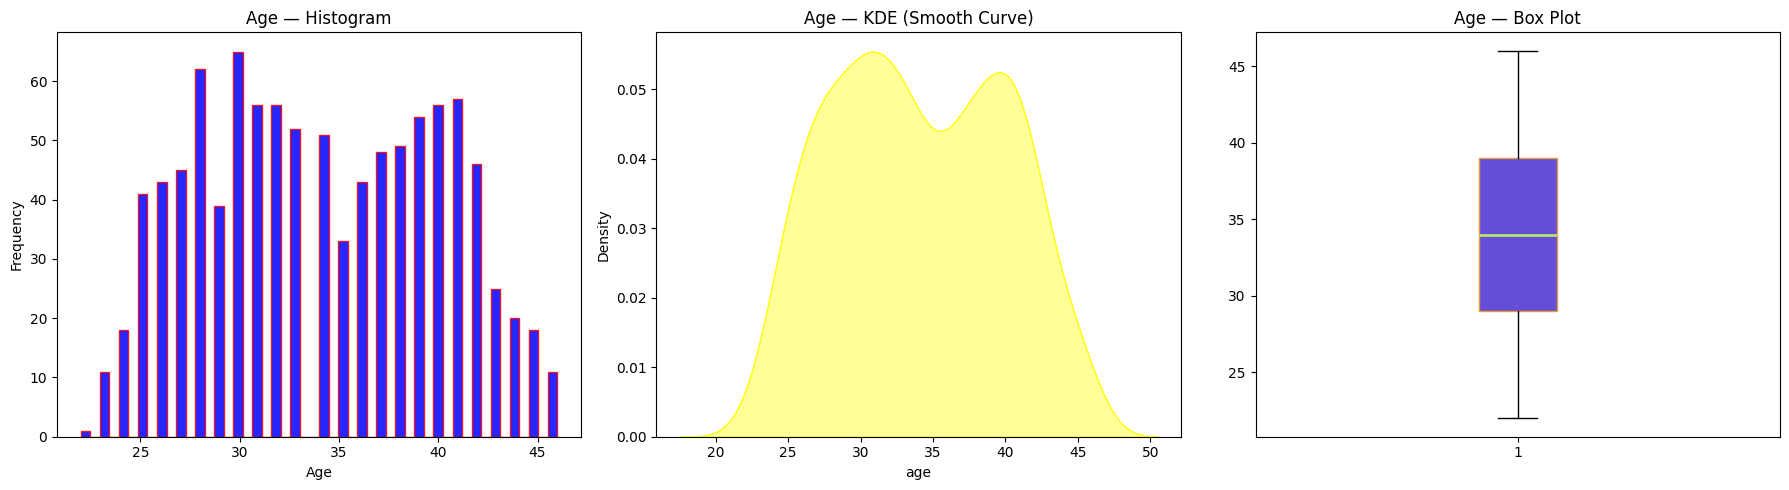

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(Data1['age'], bins=50, color='blue', edgecolor='red', alpha=0.85)
axes[0].set_title('Age — Histogram')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Frequency')

sns.kdeplot(Data1['age'], ax=axes[1], color='yellow', fill=True, alpha=0.4)
axes[1].set_title('Age — KDE (Smooth Curve)')

axes[2].boxplot(Data1['age'], patch_artist=True,
                boxprops=dict(facecolor="#664dd8", color="#e49c36"),
                medianprops=dict(color="#b7e469", linewidth=2))
axes[2].set_title('Age — Box Plot')

plt.tight_layout()
plt.show()

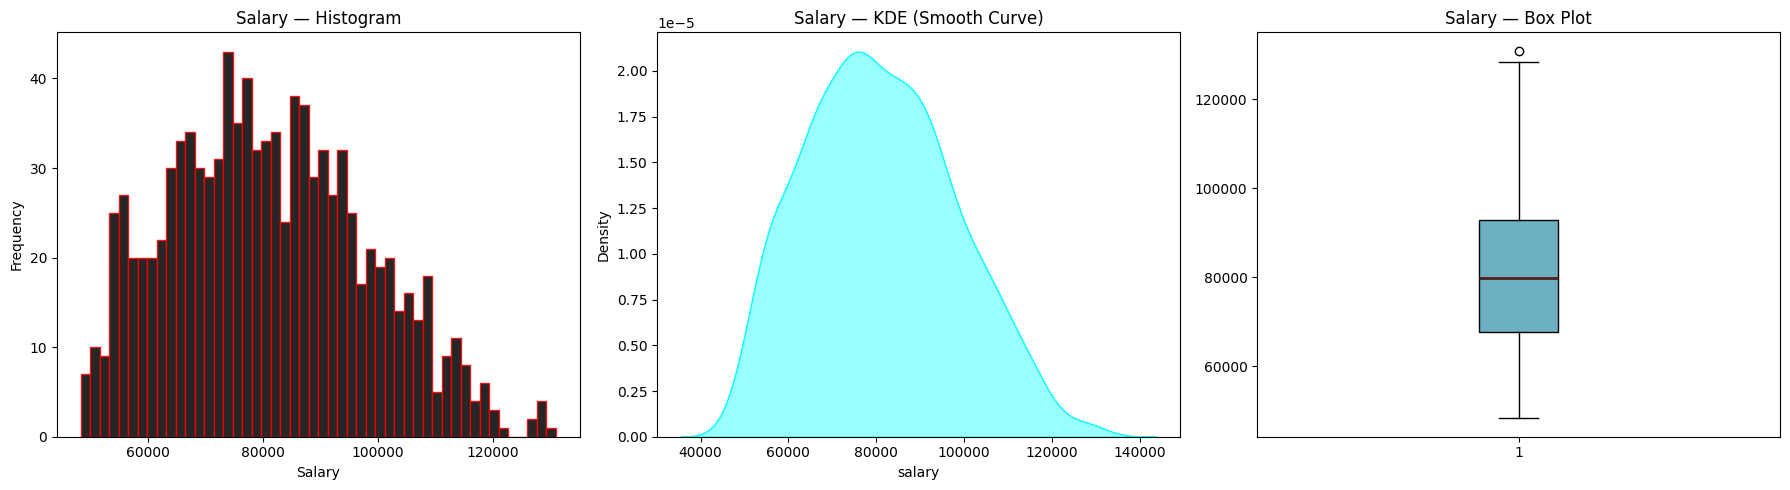

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(Data1['salary'], bins=50, color='black', edgecolor='red', alpha=0.85)
axes[0].set_title('Salary — Histogram')
axes[0].set_xlabel('Salary'); axes[0].set_ylabel('Frequency')

sns.kdeplot(Data1['salary'], ax=axes[1], color='cyan', fill=True, alpha=0.4)
axes[1].set_title('Salary — KDE (Smooth Curve)')

axes[2].boxplot(Data1['salary'], patch_artist=True,
                boxprops=dict(facecolor="#6cb0c1", color="#050505"),
                medianprops=dict(color="#521f1a", linewidth=2))
axes[2].set_title('Salary — Box Plot')

plt.tight_layout()
plt.show()

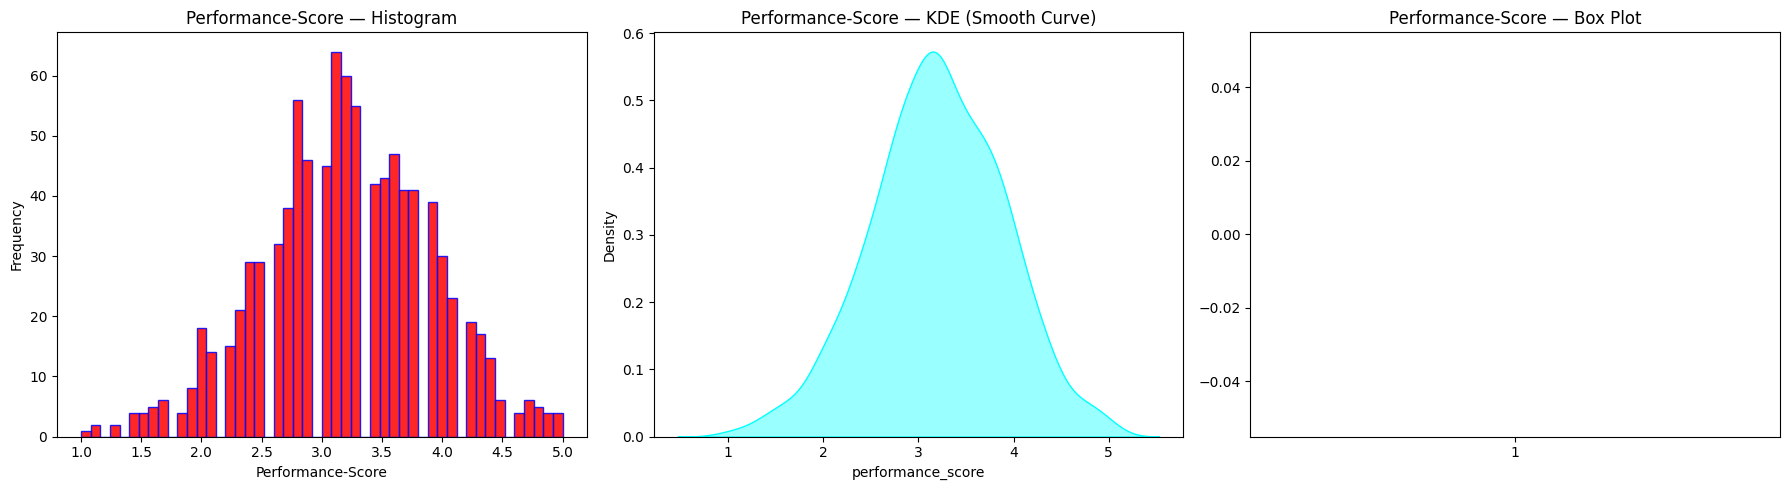

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(Data1['performance_score'], bins=50, color='red', edgecolor='blue', alpha=0.85)
axes[0].set_title('Performance-Score — Histogram')
axes[0].set_xlabel('Performance-Score'); axes[0].set_ylabel('Frequency')

sns.kdeplot(Data1['performance_score'], ax=axes[1], color='cyan', fill=True, alpha=0.4)
axes[1].set_title('Performance-Score — KDE (Smooth Curve)')

axes[2].boxplot(Data1['performance_score'], patch_artist=True,
                boxprops=dict(facecolor="#686283", color="#686283"),
                medianprops=dict(color="#040404", linewidth=2))
axes[2].set_title('Performance-Score — Box Plot')

plt.tight_layout()
plt.show()

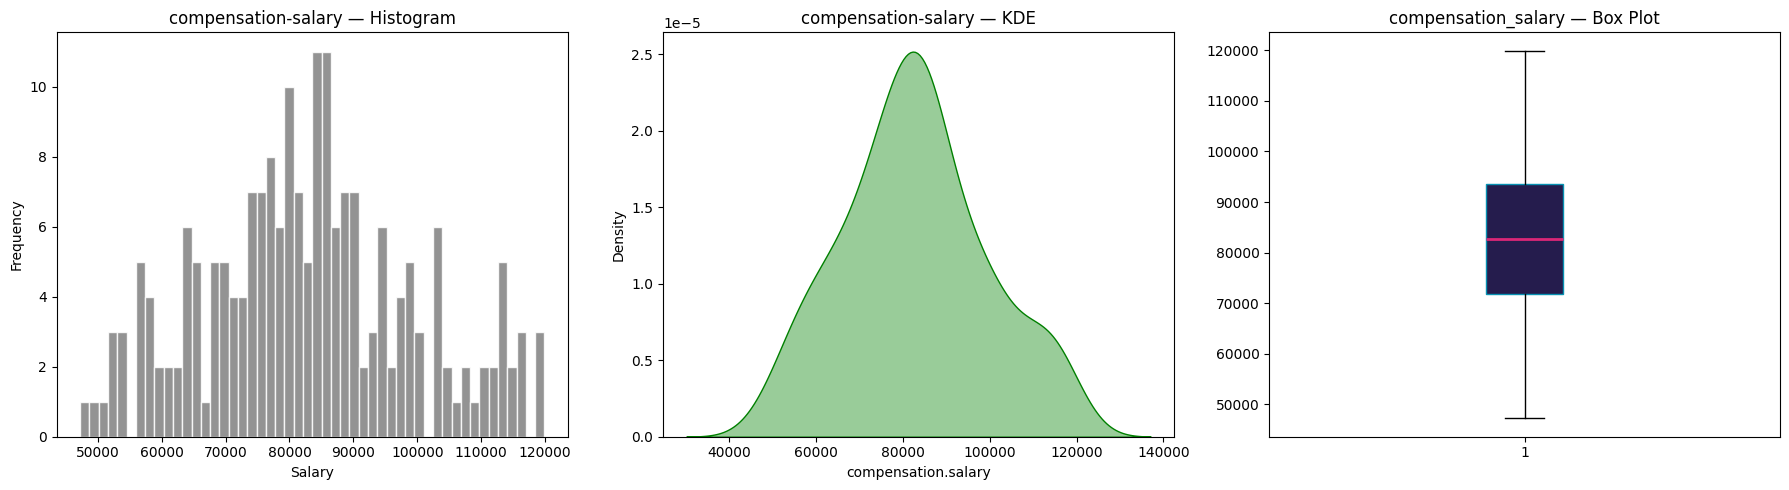

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].hist(M_Data2['compensation.salary'], bins=50, color='grey', edgecolor='white', alpha=0.85)
axes[0].set_title('compensation-salary — Histogram')
axes[0].set_xlabel('Salary'); axes[0].set_ylabel('Frequency')
 
sns.kdeplot(M_Data2['compensation.salary'], ax=axes[1], color='green', fill=True, alpha=0.4)
axes[1].set_title('compensation-salary — KDE')
 
axes[2].boxplot(M_Data2['compensation.salary'], patch_artist=True,
                boxprops=dict(facecolor='#251c4d', color='#0891b2'),
                medianprops=dict(color='#db2777', linewidth=2))
axes[2].set_title('compensation_salary — Box Plot')
 
plt.tight_layout()
plt.show()

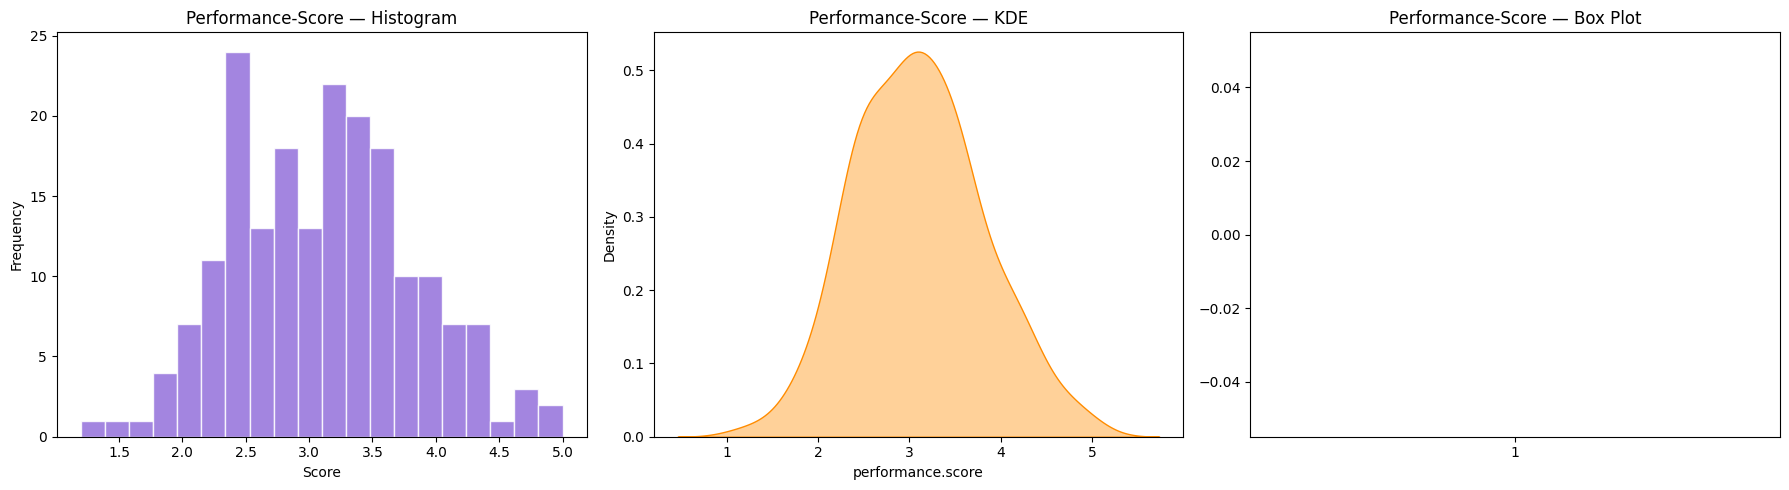

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].hist(M_Data2['performance.score'], bins=20, color='mediumpurple',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Performance-Score — Histogram')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Frequency')
 
sns.kdeplot(M_Data2['performance.score'], ax=axes[1], color='darkorange', fill=True, alpha=0.4)
axes[1].set_title('Performance-Score — KDE')
 
axes[2].boxplot(M_Data2['performance.score'], patch_artist=True,
                boxprops=dict(facecolor='#1e3a5f', color='#0891b2'),
                medianprops=dict(color='#f59e0b', linewidth=2))
axes[2].set_title('Performance-Score — Box Plot')
 
plt.tight_layout()
plt.show()

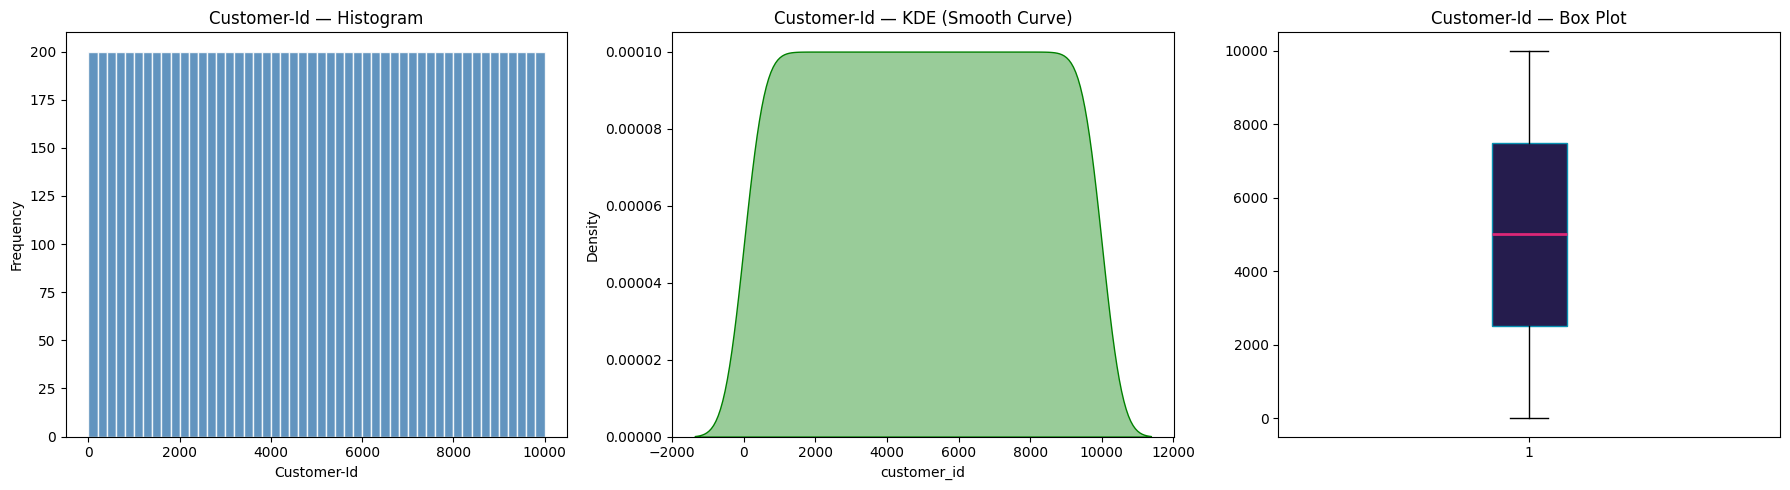

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].hist(Data3['customer_id'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Customer-Id — Histogram')
axes[0].set_xlabel('Customer-Id'); axes[0].set_ylabel('Frequency')
 
sns.kdeplot(Data3['customer_id'], ax=axes[1], color='green', fill=True, alpha=0.4)
axes[1].set_title('Customer-Id — KDE (Smooth Curve)')
 
axes[2].boxplot(Data3['customer_id'], patch_artist=True,
                boxprops=dict(facecolor='#251c4d', color='#0891b2'),
                medianprops=dict(color='#db2777', linewidth=2))
axes[2].set_title('Customer-Id — Box Plot')
 
plt.tight_layout()
plt.show()

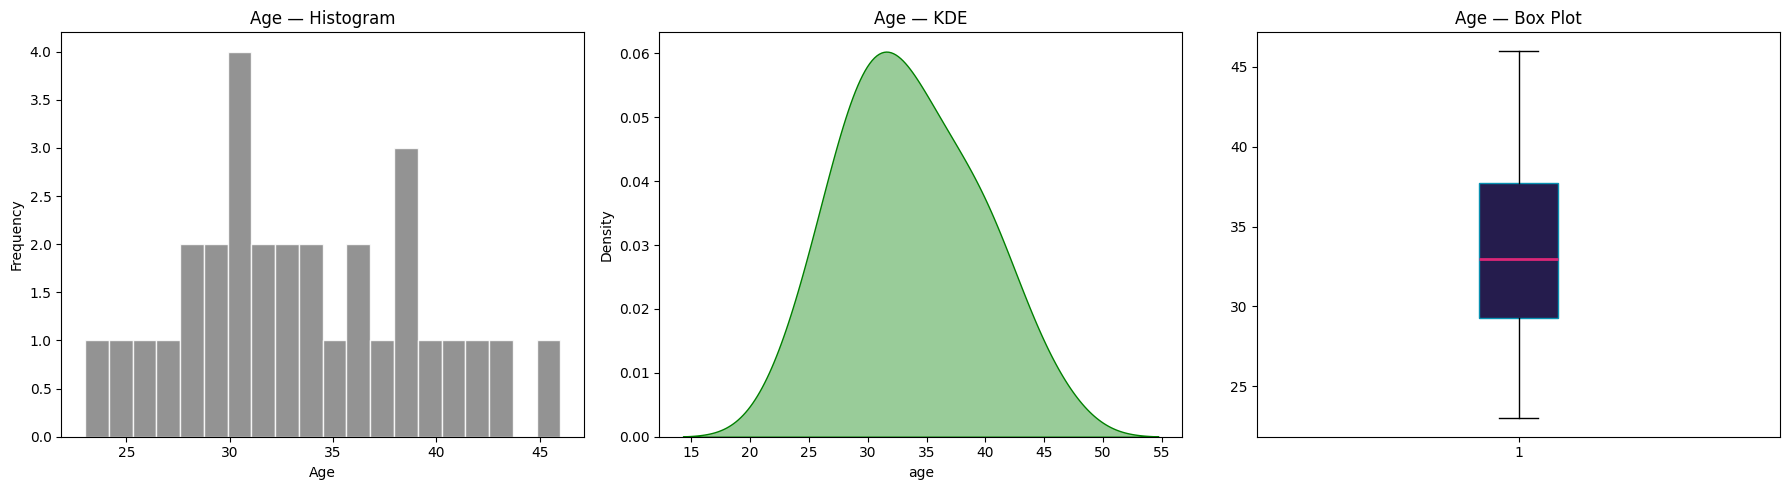

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(Data4['age'], bins=20, color='grey', edgecolor='white', alpha=0.85)
axes[0].set_title('Age — Histogram')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Frequency')
 
sns.kdeplot(Data4['age'], ax=axes[1], color='green', fill=True, alpha=0.4)
axes[1].set_title('Age — KDE')
 
axes[2].boxplot(Data4['age'], patch_artist=True,
                boxprops=dict(facecolor='#251c4d', color='#0891b2'),
                medianprops=dict(color='#db2777', linewidth=2))
axes[2].set_title('Age — Box Plot')
 
plt.tight_layout()
plt.show()

- Histogram — raw frequency distribution, bin-based
- KDE — smooth probability density curve (continuous estimate of distribution)
- Box Plot — shows median, IQR, and outliers visually

### 9)Perform Bivariate Analysis

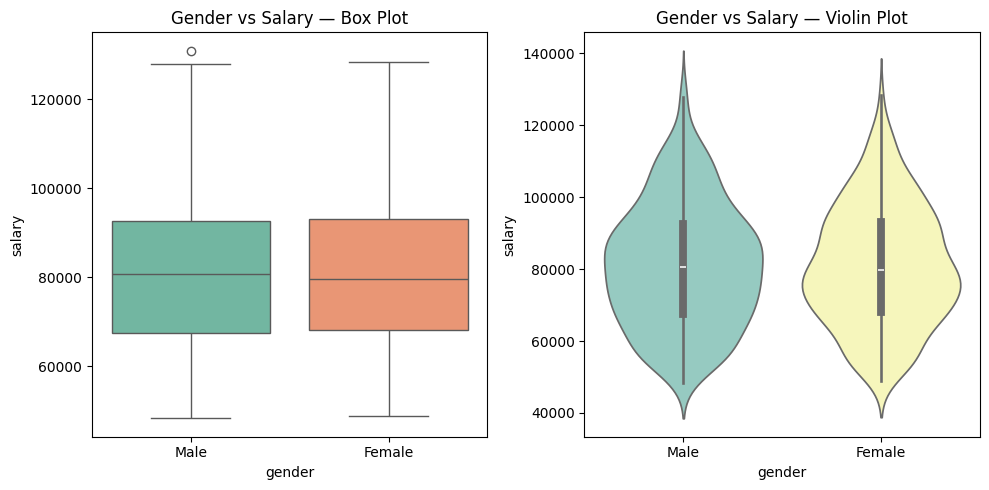

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
 
sns.boxplot(data=Data1, x='gender', y='salary',
            palette='Set2', ax=axes[0], hue='gender', legend=False)
axes[0].set_title('Gender vs Salary — Box Plot')
 
sns.violinplot(data=Data1, x='gender', y='salary',
               palette='Set3', ax=axes[1], inner='box', hue='gender', legend=False)
axes[1].set_title('Gender vs Salary — Violin Plot')
 
plt.tight_layout()
plt.show()

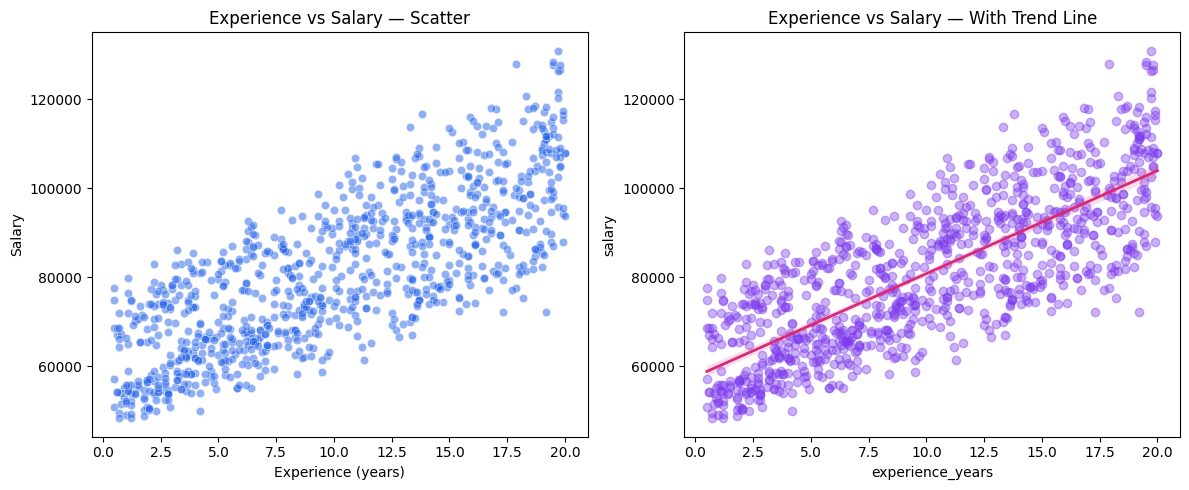

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].scatter(Data1['experience_years'], Data1['salary'],
                alpha=0.5, color='#2563eb', edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Experience (years)')
axes[0].set_ylabel('Salary')
axes[0].set_title('Experience vs Salary — Scatter')
 
sns.regplot(data=Data1, x='experience_years', y='salary',
            ax=axes[1], color='#7c3aed',
            scatter_kws={'alpha': 0.4},
            line_kws={'color': '#db2777', 'linewidth': 2})
axes[1].set_title('Experience vs Salary — With Trend Line')
 
plt.tight_layout()
plt.show()

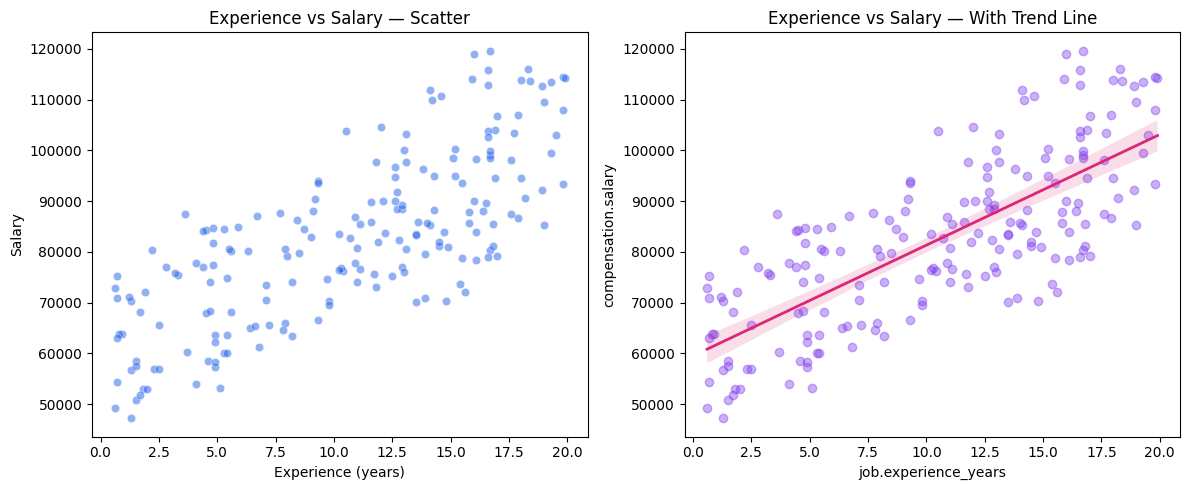

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].scatter(Data2['job.experience_years'], Data2['compensation.salary'],
                alpha=0.5, color='#2563eb', edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Experience (years)')
axes[0].set_ylabel('Salary')
axes[0].set_title('Experience vs Salary — Scatter')
 
sns.regplot(data=Data2, x='job.experience_years', y='compensation.salary',
            ax=axes[1], color='#7c3aed',
            scatter_kws={'alpha': 0.4},
            line_kws={'color': '#db2777', 'linewidth': 2})
axes[1].set_title('Experience vs Salary — With Trend Line')
 
plt.tight_layout()
plt.show()

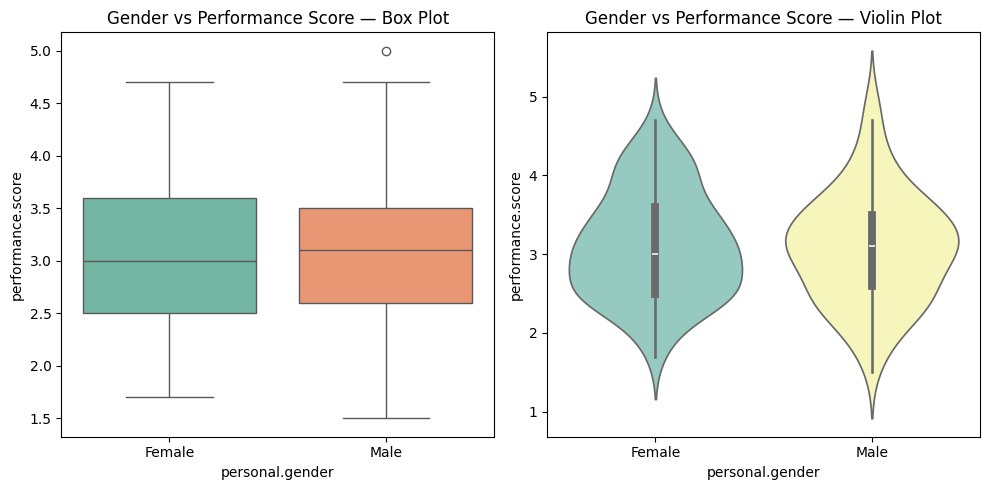

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
 
sns.boxplot(data=Data2, x='personal.gender', y='performance.score',
            palette='Set2', ax=axes[0], hue='personal.gender', legend=False)
axes[0].set_title('Gender vs Performance Score — Box Plot')
 
sns.violinplot(data=Data2, x='personal.gender', y='performance.score',
               palette='Set3', ax=axes[1], inner='box', hue='personal.gender', legend=False)
axes[1].set_title('Gender vs Performance Score — Violin Plot')
 
plt.tight_layout()
plt.show()

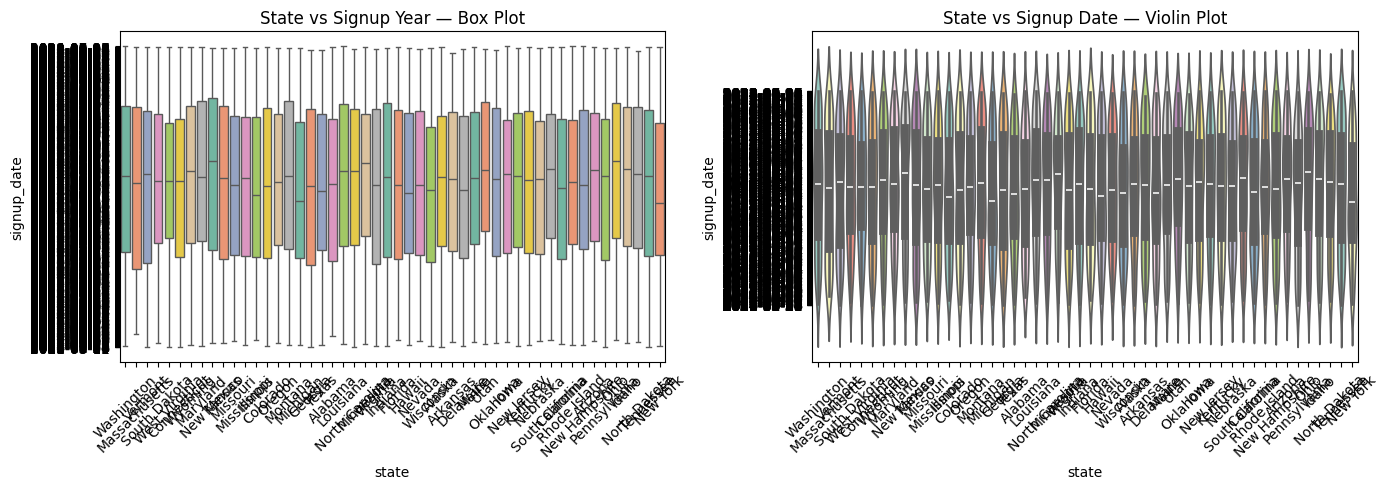

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=Data3, x='state', y='signup_date', hue='state',
            palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('State vs Signup Year — Box Plot')
axes[0].tick_params(axis='x', rotation=45)
 
sns.violinplot(data=Data3, x='state', y='signup_date', hue='state',
               palette='Set3', ax=axes[1], inner='box', legend=False)
axes[1].set_title('State vs Signup Date — Violin Plot')
axes[1].tick_params(axis='x', rotation=45)
 
plt.tight_layout()
plt.show()

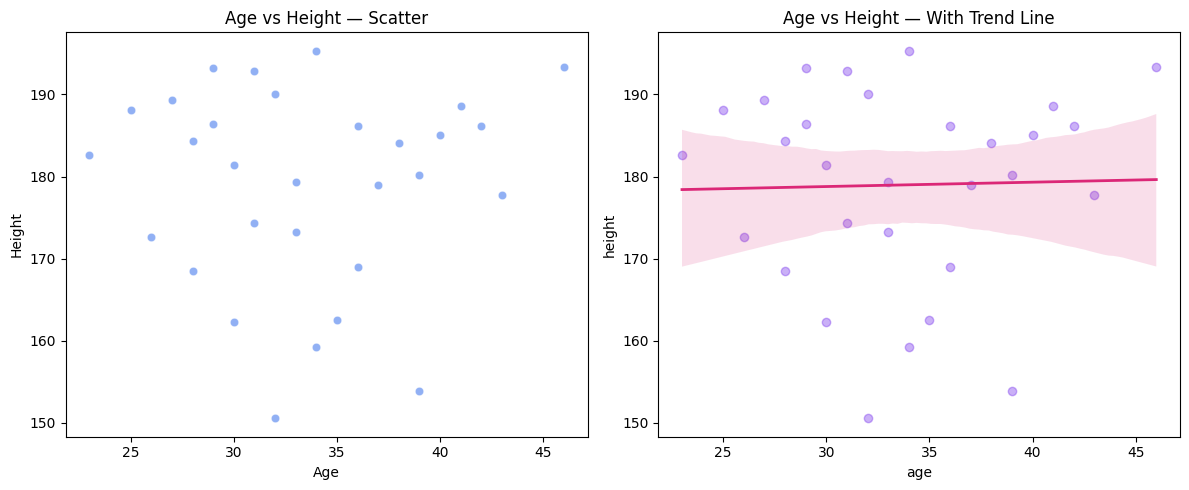

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(Data4['age'], Data4['height'],
                alpha=0.5, color='#2563eb', edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Height')
axes[0].set_title('Age vs Height — Scatter')
 
sns.regplot(data=Data4, x='age', y='height',
            ax=axes[1], color='#7c3aed',
            scatter_kws={'alpha': 0.4},
            line_kws={'color': '#db2777', 'linewidth': 2})
axes[1].set_title('Age vs Height — With Trend Line')
 
plt.tight_layout()
plt.show()

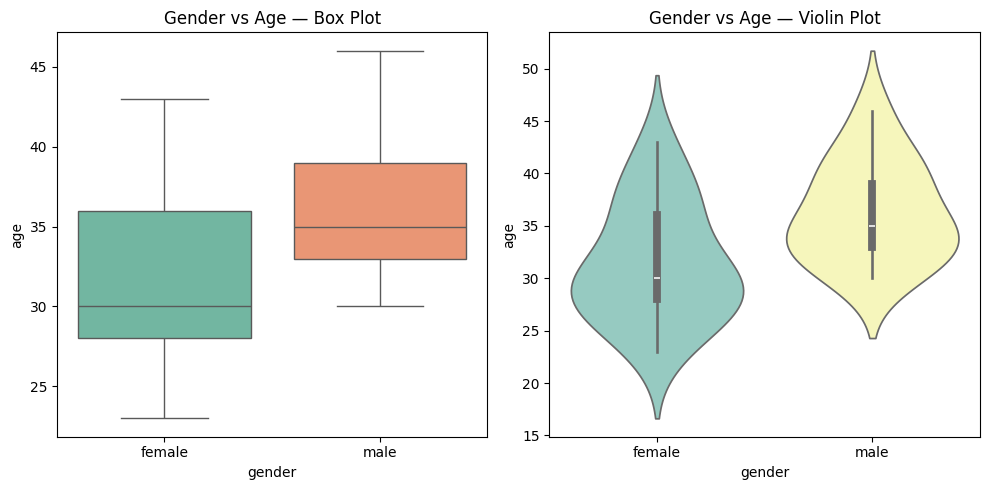

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
 
sns.boxplot(data=Data4, x='gender', y='age',
            palette='Set2', ax=axes[0], hue='gender', legend=False)
axes[0].set_title('Gender vs Age — Box Plot')
 
sns.violinplot(data=Data4, x='gender', y='age',
               palette='Set3', ax=axes[1], inner='box', hue='gender', legend=False)
axes[1].set_title('Gender vs Age — Violin Plot')
 
plt.tight_layout()
plt.show()

- sns.boxplot(x=categorical, y=numeric) = Distribution of numeric variable split by category
- sns.violinplot(...) = Same as boxplot but shows full distribution shape via KDE
- axes.scatter(x, y)Raw relationship between two numeric variables
- sns.regplot(x, y)Scatter + fitted regression trend line

### 10)Perform **Multivariate** Analysis

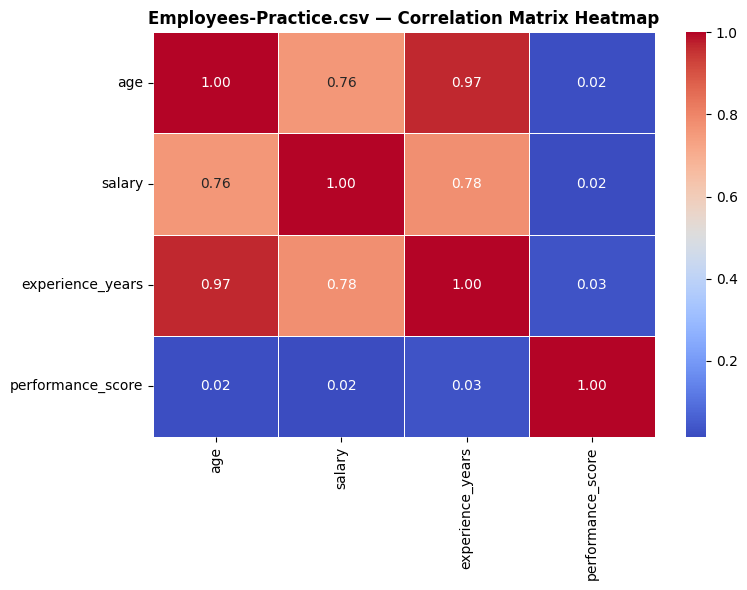

In [54]:
co_matrix = Data1.select_dtypes(include='number').corr()
 
plt.figure(figsize=(8, 6))
sns.heatmap(co_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Employees-Practice.csv — Correlation Matrix Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

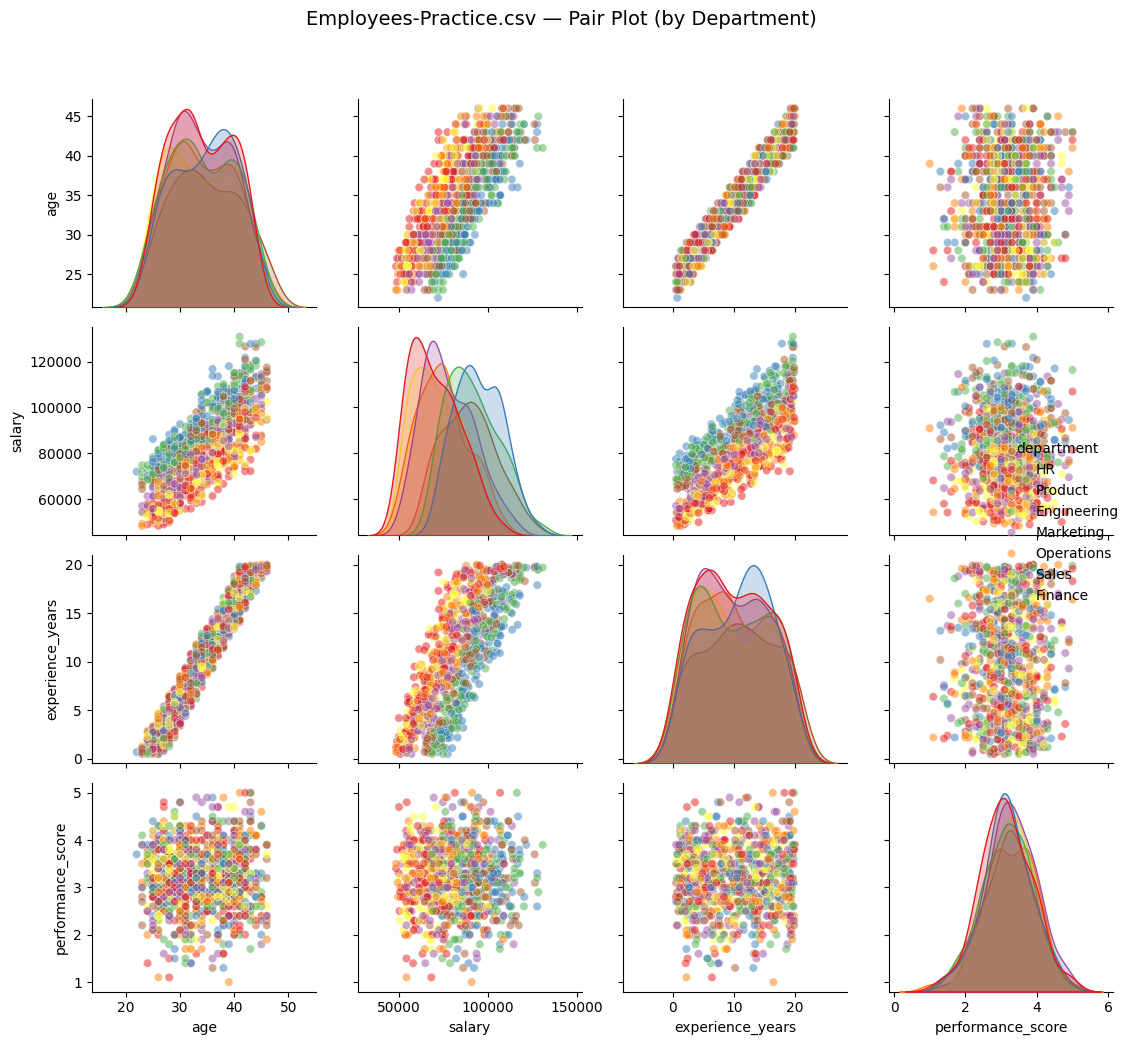

In [55]:
sns.pairplot(
    Data1[['age', 'salary', 'experience_years', 'performance_score', 'department']],
    hue='department',
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    palette='Set1'
)
plt.suptitle('Employees-Practice.csv — Pair Plot (by Department)', y=1.04, fontsize=14)
plt.tight_layout()
plt.show()

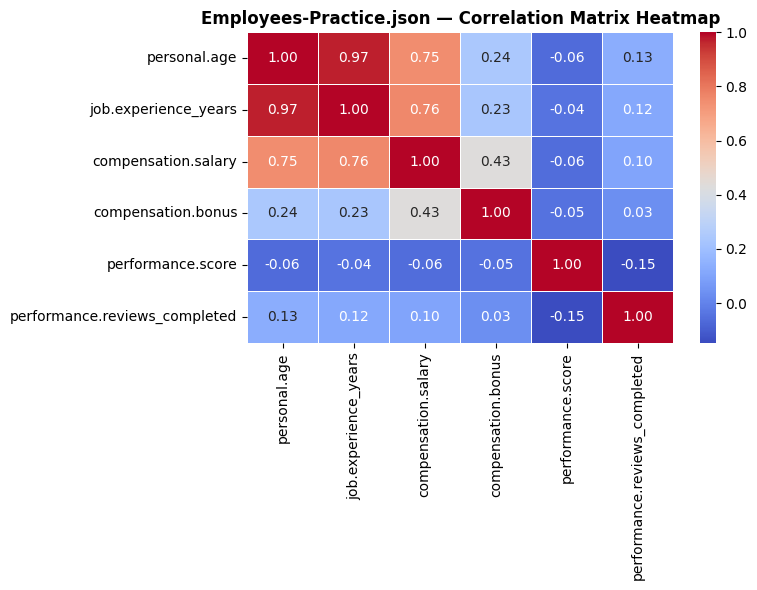

In [56]:
num_cols_j = ['personal.age', 'job.experience_years', 'compensation.salary',
              'compensation.bonus', 'performance.score', 'performance.reviews_completed']
co_matrix_j = M_Data2[num_cols_j].corr()
 
plt.figure(figsize=(8, 6))
sns.heatmap(co_matrix_j, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Employees-Practice.json — Correlation Matrix Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

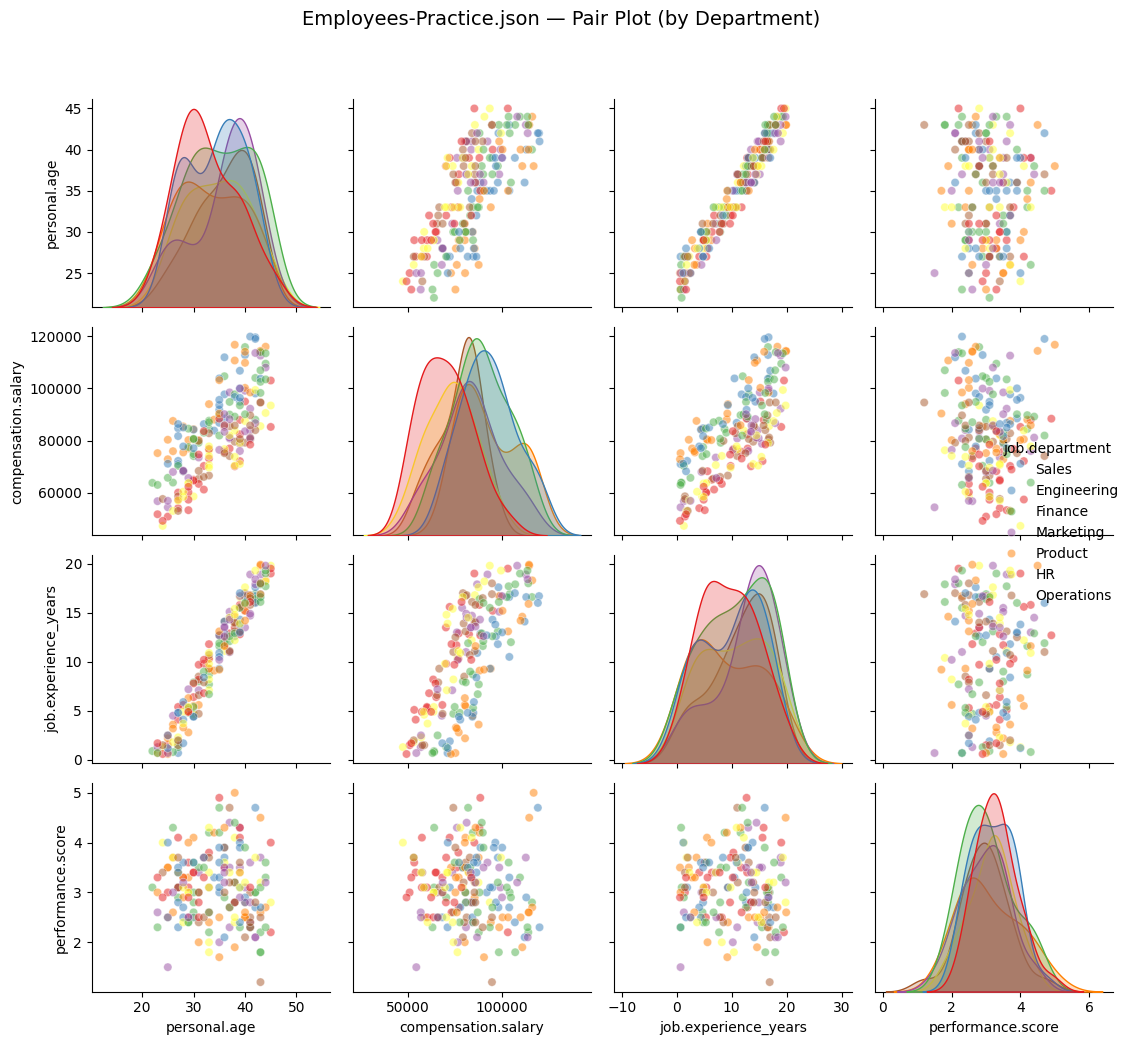

In [57]:
sns.pairplot(
    M_Data2[['personal.age', 'compensation.salary', 'job.experience_years',
             'performance.score', 'job.department']],
    hue='job.department',
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    palette='Set1'
)
plt.suptitle('Employees-Practice.json — Pair Plot (by Department)', y=1.04, fontsize=14)
plt.tight_layout()
plt.show()

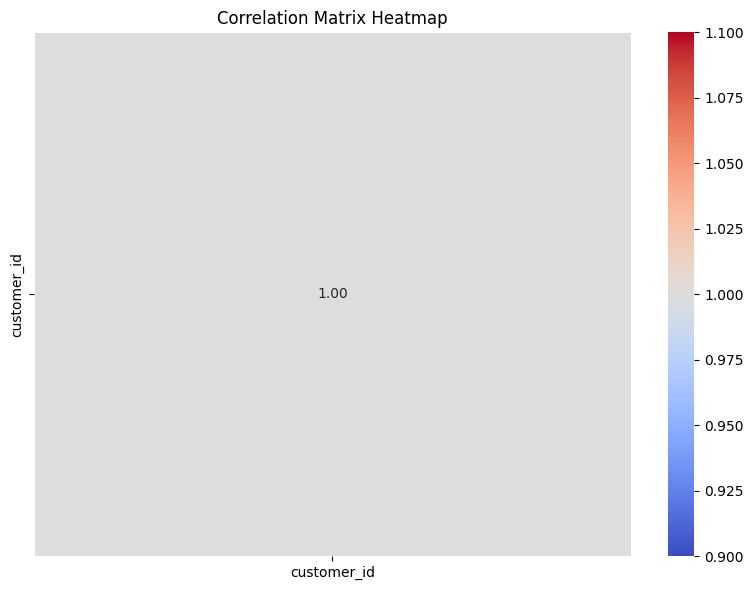

In [58]:
co_matrix = Data3.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(co_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f") 
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

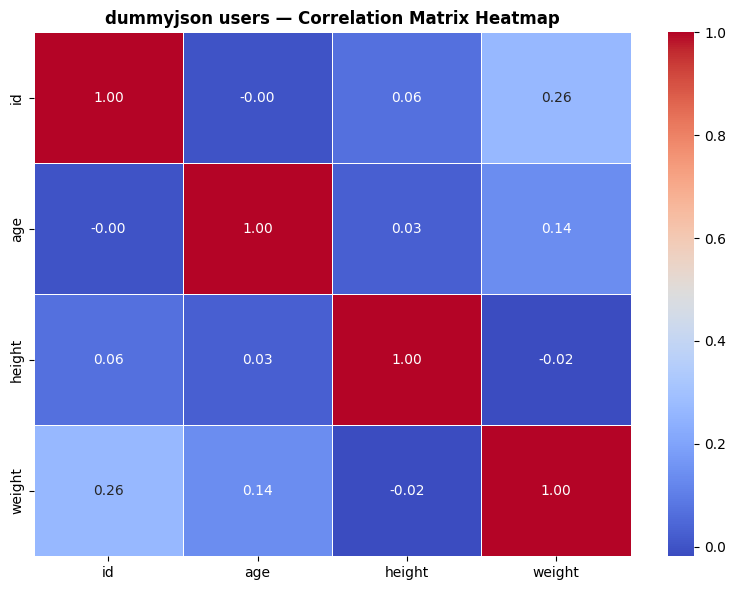

In [59]:
co_matrix_api = Data4.select_dtypes(include='number').corr()
 
plt.figure(figsize=(8, 6))
sns.heatmap(co_matrix_api, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('dummyjson users — Correlation Matrix Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

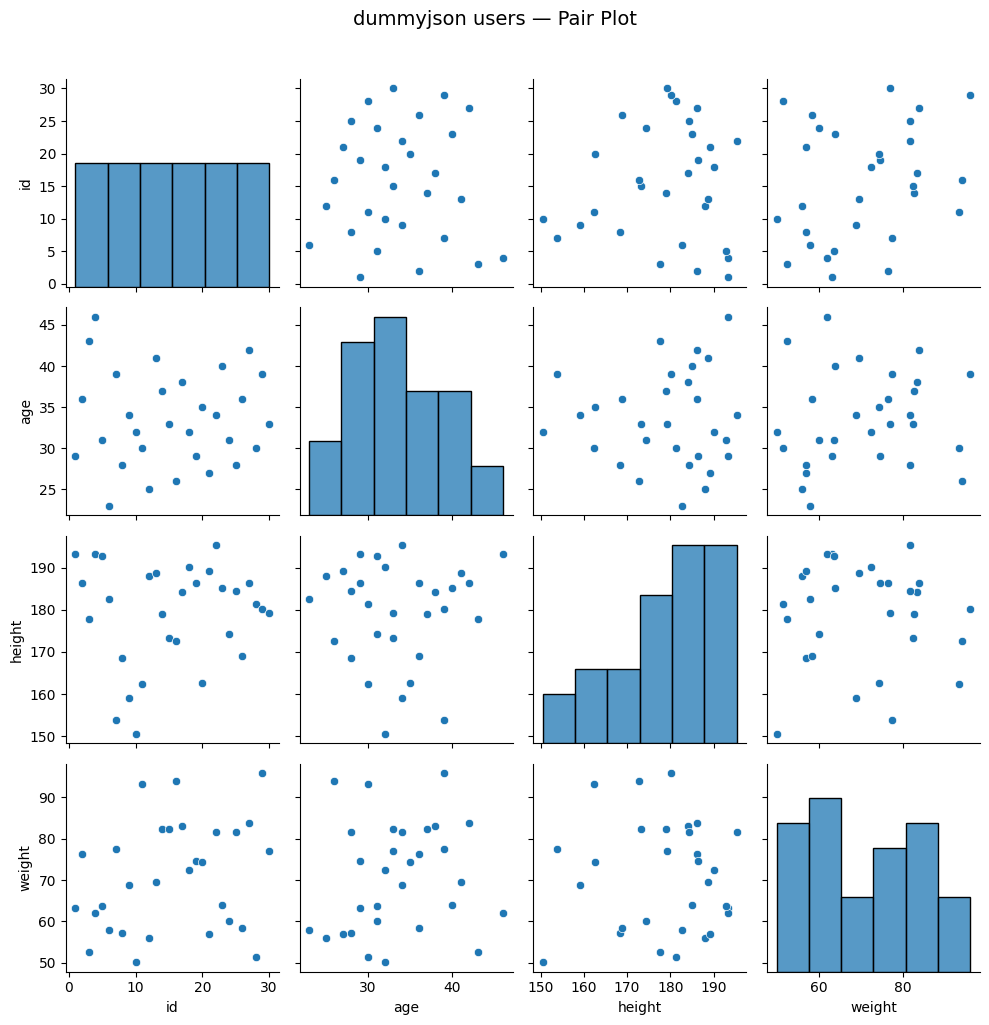

In [60]:
num_api_cols = Data4.select_dtypes(include='number').columns.tolist()
sns.pairplot(Data4[num_api_cols])
plt.suptitle('dummyjson users — Pair Plot', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Correlation Heatmap (sns.heatmap on .corr()):

- Computes Pearson correlation between all numeric columns
- Values range −1 to +1; coolwarm colormap shows positive (red) and negative (blue) correlations
- Applied to: Data1, M_Data2 (selected numeric cols), Data3, Data4

Pair Plot (sns.pairplot):

- Grid of scatter plots for every numeric pair + KDE on diagonal
- hue parameter colours points by categorical variable (e.g., department)
- Applied to: Data1 (by department), M_Data2 (by department), Data4 (all numeric cols)

In [ ]:
from ydata_profiling import ProfileReport
report = ProfileReport(Data4, title="Data Profiler Report")
report.to_file("Data-Profiler_users.html")

report = ProfileReport(Data3, title="Data Profiler Report")
report.to_file("Data-Profiler_employees.html")

report = ProfileReport(M_Data2, title="Data Profiler Report")
report.to_file("Data-Profiler_employees_practice.json.html")

report = ProfileReport(Data1, title="Data Profiler Report")
report.to_file("Data-Profiler_employees_practice.html")

